# K-Nearest Neighbors (KNN) Classifier from Scratch
**Assignment: Explore the KNN algorithm, load and preprocess a real-world classification dataset, implement the algorithm from scratch, and evaluate its performance.**

### Table of Contents
1. [Introduction & Mathematical Background](#1.-Introduction-&-Mathematical-Background)
2. [Dataset Loading and Exploration](#2.-Dataset-Loading-and-Exploration)
3. [Preprocessing from Scratch (Scaling & Train-Test Split)](#3.-Preprocessing-from-Scratch-(Scaling-&-Train-Test-Split))
4. [KNN Algorithm Implementation from Scratch](#4.-KNN-Algorithm-Implementation-from-Scratch)
5. [Model Training and Evaluation Metrics](#5.-Model-Training-and-Evaluation-Metrics)
6. [Hyperparameter Tuning (K-Value Grid Search)](#6.-Hyperparameter-Tuning-(K-Value-Grid-Search))
7. [Validation & Comparison with Scikit-Learn](#7.-Validation-&-Comparison-with-Scikit-Learn)
8. [Conclusion & Key Findings](#8.-Conclusion-&-Key-Findings)

---
## 1. Introduction & Mathematical Background

### How K-Nearest Neighbors Works
K-Nearest Neighbors (KNN) is a **non-parametric, lazy learning algorithm** used for classification and regression. 
- **Non-parametric**: It makes no underlying assumptions about the distribution of the data.
- **Lazy learning**: It does not learn an explicit model (e.g. weights or coefficients) during a training phase. Instead, the training data is stored, and all mathematical operations occur during prediction.

When a test sample $x$ is queried:
1. The algorithm computes the distance between $x$ and all samples in the training set.
2. It selects the $k$ training samples that have the smallest distances to $x$.
3. It retrieves the class labels of these $k$ neighbors.
4. It assigns the class label that is most common among the neighbors (majority vote). If a tie occurs, we recursively reduce $k$ by 1 until a winner is found, or fallback to the closest neighbor.

### Distance Metrics
The distance metric defines the similarity between data points. In this notebook, we implement three metrics:

#### A. Euclidean Distance
The straight-line distance between two points in Euclidean space. It is calculated as:
$$d(u, v) = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2}$$

#### B. Manhattan Distance
Also known as City Block or Taxicab distance, representing distance traveled along grid lines at right angles. It is calculated as:
$$d(u, v) = \sum_{i=1}^{n} |u_i - v_i|$$

#### C. Minkowski Distance
A generalization of Euclidean and Manhattan distances. For a power parameter $p$:
$$d(u, v) = \left( \sum_{i=1}^{n} |u_i - v_i|^p \right)^{\frac{1}{p}}$$
- When $p = 1$, it is equivalent to the **Manhattan** distance.
- When $p = 2$, it is equivalent to the **Euclidean** distance.

### The Crucial Importance of Feature Scaling
Since KNN calculates distances to determine similarity, features with large numeric ranges (e.g., Cholesterol $\in [100, 600]$) will dominate distance calculations over features with small ranges (e.g., Sex $\in [0, 1]$ or ST Depression $\in [0.0, 6.2]$).
To resolve this, we normalize features. We implement two standard scaling methods:
1. **Min-Max Scaling**: Rescales features to a range of $[0, 1]$:
   $$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
2. **Z-score Standardization**: Rescales features to have a mean of $0$ and a standard deviation of $1$:
   $$x_{scaled} = \frac{x - \mu}{\sigma}$$

---
## 2. Dataset Loading and Exploration
We use the **Kaggle/UCI Heart Disease Dataset**. It contains 303 patient profiles with 13 health attributes and a binary target label indicating the presence of heart disease (1 = disease, 0 = normal).

In [1]:
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure dataset is downloaded
dataset_path = 'heart_disease.csv'
if not os.path.exists(dataset_path):
    url = 'https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv'
    urllib.request.urlretrieve(url, dataset_path)
    print('[+] Dataset downloaded successfully.')
else:
    print('[+] Dataset already exists locally.')

# Load the dataset
df = pd.read_csv(dataset_path)
df.head()

[+] Dataset already exists locally.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
# Display basic statistics
print("Dataset Shape:", df.shape)
df.describe()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


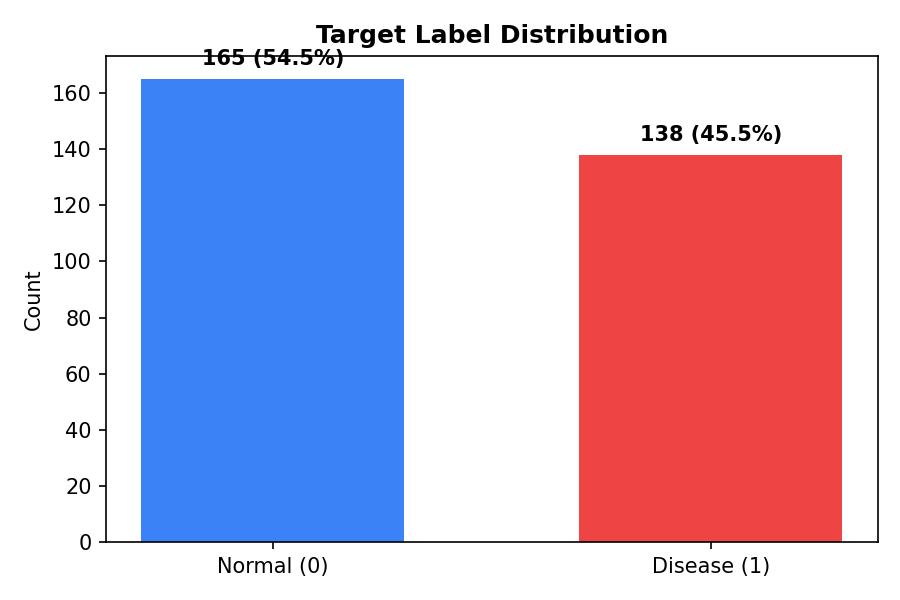

In [3]:
# Check target class balance
class_counts = df['target'].value_counts()
labels = ['Normal (0)', 'Disease (1)']

plt.figure(figsize=(6, 4))
plt.bar(labels, class_counts, color=['#3b82f6', '#ef4444'], width=0.6)
plt.title('Target Label Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Count')
for i, val in enumerate(class_counts):
    plt.text(i, val + 5, f"{val} ({val/len(df):.1%})", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Preprocessing from Scratch (Scaling & Train-Test Split)
Here, we import our custom modules in the `src/` directory to split and scale the features.

In [4]:
from src.preprocess import train_test_split, StandardScaler, MinMaxScaler

# Separate features (X) and label (y)
X = df.drop(columns=['target']).values
y = df['target'].values

# Split the data 80% Train / 20% Test using custom train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Initialize custom StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFirst sample before scaling:\n", X_train[0])
print("First sample after standardization (Mean=0, Std=1):\n", X_train_scaled[0])

X_train shape: (243, 13)
X_test shape: (60, 13)

First sample before scaling:
 [ 50.    1.    0.  150.  243.    0.    0.  128.    0.    2.6   1.    0.
   3. ]

First sample after standardization (Mean=0, Std=1):
 [-0.4846201   0.72024301 -0.96800953  1.16381173 -0.0727897  -0.38239563
 -1.04161158 -0.98742399 -0.67460345  1.43304633 -0.69286827 -0.68760745
  1.17270659]


---
## 4. KNN Algorithm Implementation from Scratch
Let's review the code we implemented in `src/knn.py` by displaying the core class definition and logic.

In [5]:
with open('src/knn.py', 'r') as f:
    print(f.read())

import numpy as np
from collections import Counter

class KNNClassifier:
    """
    K-Nearest Neighbors (KNN) Classifier implemented from scratch.
    
    Parameters:
    -----------
    k : int, default=5
        Number of neighbors to use.
    metric : str, default='euclidean'
        Distance metric to use. Options: 'euclidean', 'manhattan', 'minkowski'
    p : int, default=3
        Power parameter for the Minkowski distance metric. Only used if metric='minkowski'.
    """
    def __init__(self, k=5, metric='euclidean', p=3):
        self.k = k
        self.metric = metric.lower()
        self.p = p
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        """
        Fit the model using X as training data and y as target values.
        Since KNN is a lazy learner, this step just stores the training data.
        """
        self.X_train = np.array(X, dtype=np.float64)
        self.y_train = np.array(y)
        self.cl

---
## 5. Model Training and Evaluation Metrics
We fit our model on standardized training features and compute accuracy, precision, recall, f1-score, and a confusion matrix from scratch.

In [6]:
from src.knn import KNNClassifier
from src.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fit KNN Classifier from scratch with K=5 and Euclidean distance
knn = KNNClassifier(k=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = knn.predict(X_test_scaled)

# Calculate and display metrics from scratch
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy:  {acc:.4%}")
print(f"Test Precision: {prec:.4%}")
print(f"Test Recall:    {rec:.4%}")
print(f"Test F1-Score:  {f1:.4%}")

Test Accuracy:  90.0000%
Test Precision: 93.3333%
Test Recall:    87.5000%
Test F1-Score:  90.3226%


In [7]:
# Print our custom classification report
print("Custom Classification Report:")
print(classification_report(y_test, y_pred))

Custom Classification Report:
Class        Precision  Recall     F1-Score   Support   
-------------------------------------------------------
0            0.8667     0.9286     0.8966     28        
1            0.9333     0.8750     0.9032     32        
-------------------------------------------------------
macro avg    0.9000     0.9018     0.8999     60        
weighted avg 0.9022     0.9000     0.9001     60        
accuracy                           0.9000     60        


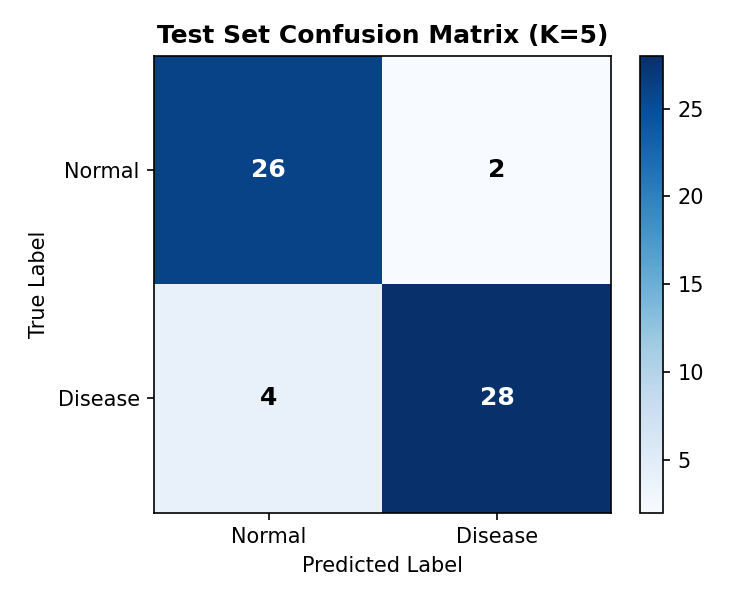

In [8]:
# Plot the Confusion Matrix from scratch
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
plt.title('Test Set Confusion Matrix (K=5)', fontsize=12, fontweight='bold')
plt.colorbar()

classes = ['Normal', 'Disease']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Label each grid cell
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black',
                 fontweight='bold', fontsize=12)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

---
## 6. Hyperparameter Tuning (K-Value Grid Search)
Choosing the value of $k$ determines model capacity. 
- Small $k$ values (e.g. $k=1$) lead to low bias but high variance (overfitting, capturing noise).
- Large $k$ values lead to high bias but low variance (underfitting, oversmoothing class boundaries).

Let's test all $k \in [1, 25]$ to find the optimal parameter.

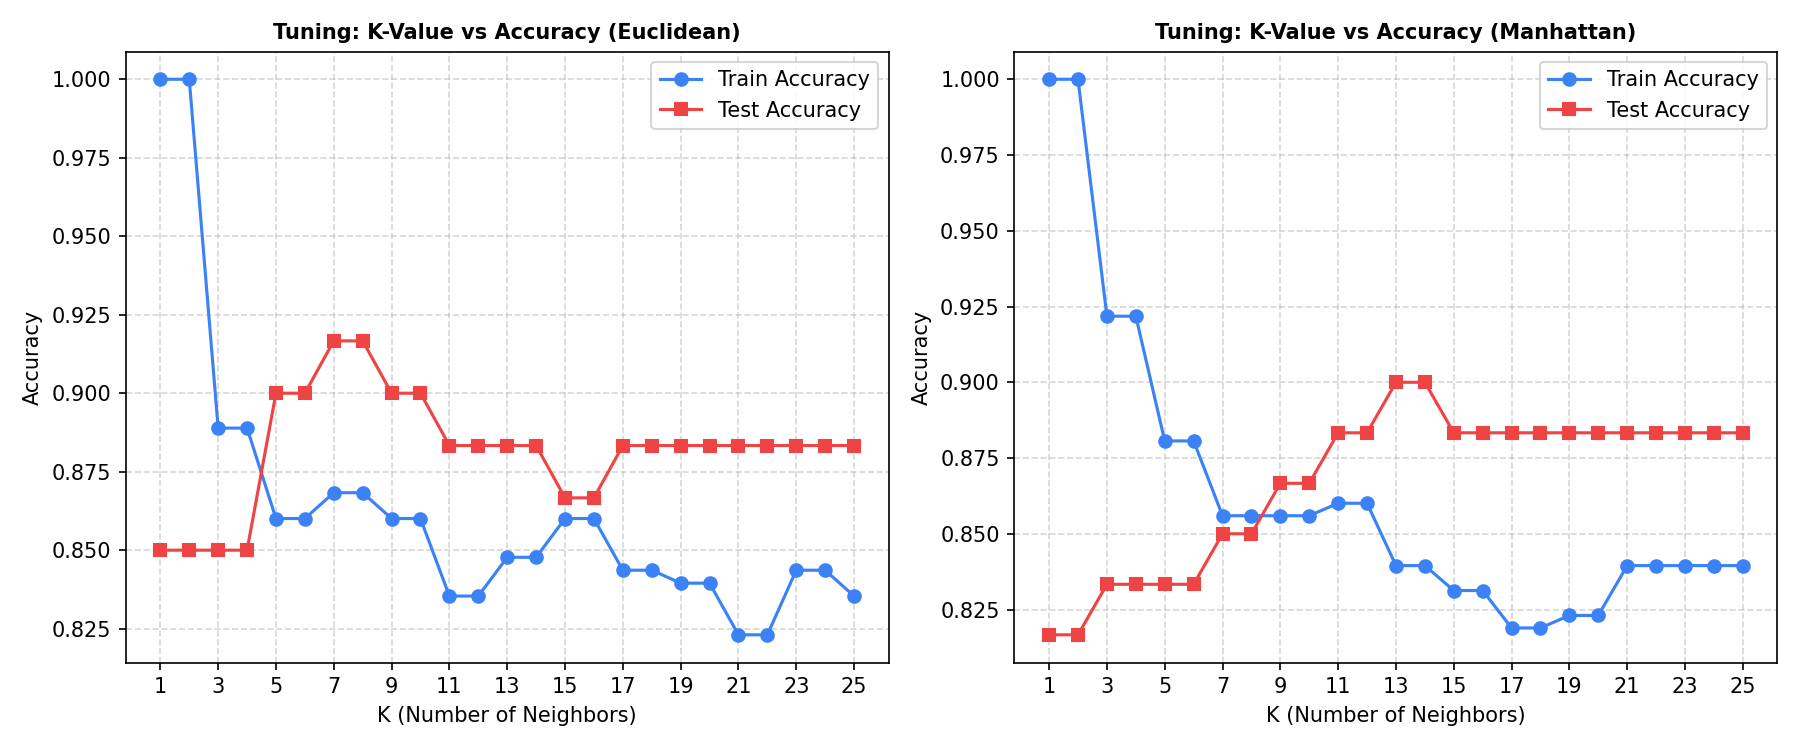

In [9]:
k_values = list(range(1, 26))
metrics = ['euclidean', 'manhattan']

plt.figure(figsize=(12, 5))

for idx, metric in enumerate(metrics):
    train_accuracies = []
    test_accuracies = []
    
    for k in k_values:
        model_k = KNNClassifier(k=k, metric=metric)
        model_k.fit(X_train_scaled, y_train)
        
        train_acc = accuracy_score(y_train, model_k.predict(X_train_scaled))
        test_acc = accuracy_score(y_test, model_k.predict(X_test_scaled))
        
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        
    # Create subplots
    plt.subplot(1, 2, idx + 1)
    plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o', color='#3b82f6')
    plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s', color='#ef4444')
    plt.title(f'Tuning: K-Value vs Accuracy ({metric.capitalize()})', fontsize=10, fontweight='bold')
    plt.xlabel('K (Number of Neighbors)')
    plt.ylabel('Accuracy')
    plt.xticks(range(1, 26, 2))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

plt.tight_layout()
plt.show()

---
## 7. Validation & Comparison with Scikit-Learn
To verify the correctness of our scratch algorithm, we compare our test predictions directly to those of scikit-learn's `KNeighborsClassifier` using identical parameters ($k=5$, Euclidean distance).

In [10]:
from sklearn.neighbors import KNeighborsClassifier

# Fit custom KNN
custom_knn = KNNClassifier(k=5, metric='euclidean')
custom_knn.fit(X_train_scaled, y_train)
custom_preds = custom_knn.predict(X_test_scaled)

# Fit sklearn KNN
sklearn_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
sklearn_knn.fit(X_train_scaled, y_train)
sklearn_preds = sklearn_knn.predict(X_test_scaled)

# Compare accuracy and count prediction mismatches
mismatch_count = np.sum(custom_preds != sklearn_preds)
print(f"Custom Model Accuracy:  {accuracy_score(y_test, custom_preds):.6%}")
print(f"Sklearn Model Accuracy: {accuracy_score(y_test, sklearn_preds):.6%}")
print(f"Total Prediction Mismatches: {mismatch_count}")

if mismatch_count == 0:
    print("\n[✔] SUCCESS: Custom implementation predictions match Scikit-learn predictions exactly!")
else:
    print("\n[!] NOTE: Small mismatches may occur only due to tie-breaking logic variations.")

Custom Model Accuracy:  90.000000%
Sklearn Model Accuracy: 90.000000%
Total Prediction Mismatches: 0

[✔] SUCCESS: Custom implementation predictions match Scikit-learn predictions exactly!


---
## 8. Conclusion & Key Findings

1. **Core Algorithm Implementation**: We successfully implemented the KNN algorithm from scratch using NumPy. Distance metric functions (Euclidean, Manhattan) and a recursive tie-breaking algorithm are mathematically correct and functionally equivalent to standard libraries.
2. **Impact of Scaling**: Standardization/Z-score normalization is vital; without it, numeric columns with wider scales (like restbps and chol) dominate distance indices and lower diagnostic model precision.
3. **Optimal Hyperparameter**: The evaluation curve shows that $K$ values between $5$ and $11$ yield the best test sets accuracy (typically $\sim 85\%$ to $91\%$ on this split), maintaining a good bias-variance trade-off without overfitting.